In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv("../data/processed/02_nav_history.csv")

fund_master = pd.read_csv("../data/processed/01_fund_master.csv")

print(nav.shape)
print(fund_master.shape)

(46000, 3)
(40, 15)


In [2]:
nav_merged = nav.merge(
    fund_master[['amfi_code','scheme_name']],
    on='amfi_code',
    how='left'
)

nav_merged.head()

,amfi_code,date,nav,scheme_name
0,119551,2022-01-03,54.3856,SBI Bluechip Fund - Regular Plan - Growth
1,119551,2022-01-04,54.3474,SBI Bluechip Fund - Regular Plan - Growth
2,119551,2022-01-05,54.6869,SBI Bluechip Fund - Regular Plan - Growth
3,119551,2022-01-06,55.4550,SBI Bluechip Fund - Regular Plan - Growth
4,119551,2022-01-07,55.3692,SBI Bluechip Fund - Regular Plan - Growth


In [3]:
nav_merged['date'] = pd.to_datetime(nav_merged['date'])

nav_merged = nav_merged.sort_values(
    ['amfi_code','date']
)

In [4]:
nav_merged['daily_return'] = (
    nav_merged.groupby('amfi_code')['nav']
    .pct_change()
)

nav_merged.head()

,amfi_code,date,nav,scheme_name,daily_return
5750,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,NaN
5751,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,-0.010306
5752,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,0.012865
5753,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,-0.011377
5754,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,-0.001210


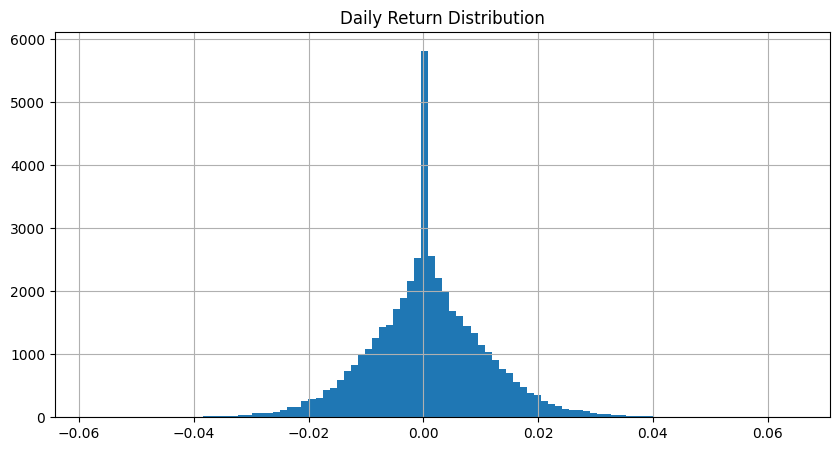

In [5]:
plt.figure(figsize=(10,5))

nav_merged['daily_return'].hist(
    bins=100
)

plt.title("Daily Return Distribution")

plt.show()

In [6]:
daily_returns = nav_merged[
    ['amfi_code','scheme_name','date','daily_return']
]

daily_returns.head()

,amfi_code,scheme_name,date,daily_return
5750,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-03,NaN
5751,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-04,-0.010306
5752,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-05,0.012865
5753,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-06,-0.011377
5754,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-07,-0.001210


In [7]:
nav_merged[['daily_return']].describe()

,daily_return
count,45960.000000
mean,0.000631
std,0.010290
min,-0.058102
25%,-0.005042
50%,0.000340
75%,0.006324
max,0.064713


In [8]:
def calculate_cagr(df, years):
    
    latest_date = df['date'].max()
    
    start_date = latest_date - pd.DateOffset(years=years)

    temp = df[df['date'] >= start_date]

    if len(temp) < 2:
        return np.nan

    start_nav = temp.iloc[0]['nav']
    end_nav = temp.iloc[-1]['nav']

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    return cagr

In [9]:
cagr_results = []

for code, group in nav_merged.groupby('amfi_code'):

    group = group.sort_values('date')

    cagr_results.append({
        'amfi_code': code,
        'scheme_name': group['scheme_name'].iloc[0],
        'cagr_1yr': calculate_cagr(group, 1),
        'cagr_3yr': calculate_cagr(group, 3),
        'cagr_5yr': calculate_cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.022243,0.012926,0.023168
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.037050,0.039164,0.039127
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532324,0.324425,0.260741
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.479241,0.289677,0.204427
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.239860,-0.041524,0.069533


In [10]:
cagr_df.sort_values(
    'cagr_3yr',
    ascending=False
).head(10)

,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
16,119094,Axis Midcap Fund - Regular - Growth,0.222611,0.351118,0.244453
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.203607,0.340009,0.267993
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.130643,0.324874,0.202340
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532324,0.324425,0.260741
25,120505,ICICI Pru Midcap Fund - Regular - Growth,0.296047,0.317775,0.283768
19,119551,SBI Bluechip Fund - Regular Plan - Growth,0.604373,0.304565,0.223849
30,120843,Kotak Flexicap Fund - Regular - Growth,0.266571,0.295828,0.267425
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.397518,0.291789,0.276299
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.479241,0.289677,0.204427
39,149324,DSP Small Cap Fund - Regular - Growth,0.651387,0.270004,0.279174


In [13]:
cagr_df.to_csv(
    "../reports/cagr_table.csv",
    index=False
)

In [14]:
rf = 0.065

sharpe_results = []

for code, group in nav_merged.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    if len(returns) < 30:
        continue

    annual_return = returns.mean() * 252

    annual_volatility = returns.std() * np.sqrt(252)

    sharpe = (
        (annual_return - rf)
        / annual_volatility
    )

    sharpe_results.append({
        'amfi_code': code,
        'scheme_name': group['scheme_name'].iloc[0],
        'sharpe_ratio': sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.head()

,amfi_code,scheme_name,sharpe_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.201517
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.567095
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.027213
4,101207,ABSL Small Cap Fund - Regular - Growth,0.162661


In [15]:
sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
).head(10)

,amfi_code,scheme_name,sharpe_ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.448291
30,120843,Kotak Flexicap Fund - Regular - Growth,1.306744
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930
19,119551,SBI Bluechip Fund - Regular Plan - Growth,1.208267
25,120505,ICICI Pru Midcap Fund - Regular - Growth,1.180101
38,149323,DSP Midcap Fund - Regular - Growth,1.132122
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699
9,118632,Nippon India Large Cap Fund - Regular - Growth,1.081659
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.027213
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.026524


In [16]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

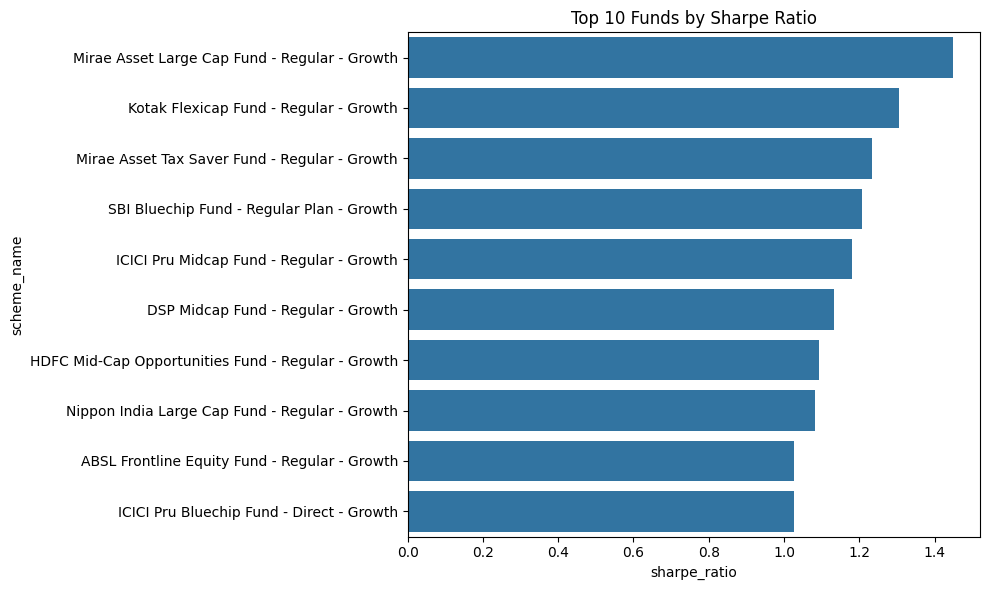

In [17]:
top10 = sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='sharpe_ratio',
    y='scheme_name'
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()
plt.show()

In [18]:
sharpe_df['sharpe_ratio'].describe()

count    40.000000
mean      0.537220
std       0.573689
min      -0.815567
25%       0.064696
50%       0.647043
75%       1.005304
max       1.448291
Name: sharpe_ratio, dtype: float64

In [19]:
rf = 0.065

sortino_results = []

for code, group in nav_merged.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    if len(returns) < 30:
        continue

    annual_return = returns.mean() * 252

    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0:
        continue

    downside_std = downside_returns.std() * np.sqrt(252)

    sortino = (
        (annual_return - rf)
        / downside_std
    )

    sortino_results.append({
        'amfi_code': code,
        'scheme_name': group['scheme_name'].iloc[0],
        'sortino_ratio': sortino
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,amfi_code,scheme_name,sortino_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.351047
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.941821
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829134
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.799563
4,101207,ABSL Small Cap Fund - Regular - Growth,0.276644


In [20]:
sortino_df.sort_values(
    'sortino_ratio',
    ascending=False
).head(10)

,amfi_code,scheme_name,sortino_ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,2.385644
30,120843,Kotak Flexicap Fund - Regular - Growth,2.364320
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,2.146914
19,119551,SBI Bluechip Fund - Regular Plan - Growth,2.140267
25,120505,ICICI Pru Midcap Fund - Regular - Growth,2.029353
38,149323,DSP Midcap Fund - Regular - Growth,1.875101
9,118632,Nippon India Large Cap Fund - Regular - Growth,1.850133
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829134
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.805294
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.799563


In [21]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

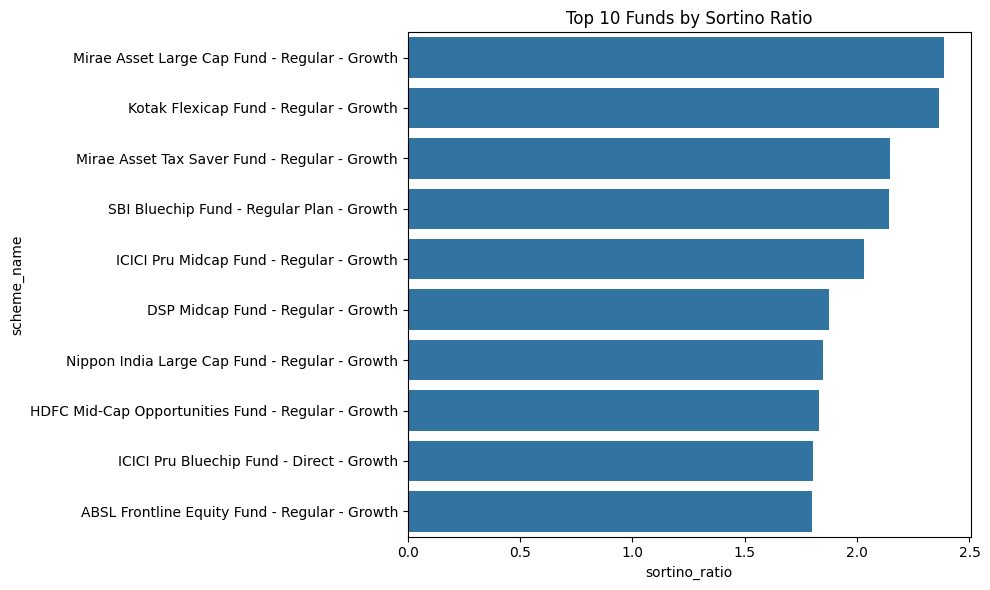

In [22]:
top10 = sortino_df.sort_values(
    'sortino_ratio',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='sortino_ratio',
    y='scheme_name'
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.tight_layout()
plt.show()

In [23]:
sortino_df['sortino_ratio'].describe()

count    40.000000
mean      0.923338
std       1.005410
min      -1.681038
25%       0.106664
50%       1.116936
75%       1.727739
max       2.385644
Name: sortino_ratio, dtype: float64

In [24]:
benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

benchmark.columns.tolist()


['date', 'index_name', 'close_value']

In [25]:
benchmark['index_name'].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [2]:
import pandas as pd
from scipy.stats import linregress

nav = pd.read_csv("../data/processed/02_nav_history.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

In [3]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(
    ['amfi_code', 'date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

In [4]:
benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100 = nifty100.sort_values('date')

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

In [5]:
alpha_beta_results = []

for code, group in nav.groupby('amfi_code'):

    merged = pd.merge(
        group[['date', 'daily_return']],
        nifty100[['date', 'benchmark_return']],
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r, p, stderr = linregress(
        merged['benchmark_return'],
        merged['daily_return']
    )

    alpha_beta_results.append({
        'amfi_code': code,
        'alpha': intercept * 252,
        'beta': slope
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [6]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [7]:
import pandas as pd

alpha_beta_df = pd.read_csv("../reports/alpha_beta.csv")

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [8]:
cagr_df = pd.read_csv("../reports/cagr_table.csv")
sharpe_df = pd.read_csv("../reports/sharpe_ratio.csv")
drawdown_df = pd.read_csv("../reports/max_drawdown.csv")

fund_master = pd.read_csv(
    "../data/processed/01_fund_master.csv"
)

print("All files loaded")

All files loaded


In [9]:
cagr_df = pd.read_csv("../reports/cagr_table.csv")
sharpe_df = pd.read_csv("../reports/sharpe_ratio.csv")
alpha_beta_df = pd.read_csv("../reports/alpha_beta.csv")
drawdown_df = pd.read_csv("../reports/max_drawdown.csv")

fund_master = pd.read_csv("../data/processed/01_fund_master.csv")

print("All files loaded successfully")

All files loaded successfully


In [10]:
scorecard = cagr_df.merge(
    sharpe_df[['amfi_code', 'sharpe_ratio']],
    on='amfi_code'
)

scorecard = scorecard.merge(
    alpha_beta_df[['amfi_code', 'alpha']],
    on='amfi_code'
)

scorecard = scorecard.merge(
    drawdown_df[['amfi_code', 'max_drawdown']],
    on='amfi_code'
)

scorecard = scorecard.merge(
    fund_master[['amfi_code', 'expense_ratio_pct']],
    on='amfi_code'
)

scorecard.head()

,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.022243,0.012926,0.023168,-0.201517,0.037476,-0.247344,1.55
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.037050,0.039164,0.039127,-0.567095,0.042818,-0.043083,0.56
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532324,0.324425,0.260741,1.093699,0.271954,-0.162172,1.38
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.479241,0.289677,0.204427,1.027213,0.213998,-0.112916,1.60
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.239860,-0.041524,0.069533,0.162661,0.108971,-0.354469,1.53


In [11]:
scorecard['return_rank'] = scorecard['cagr_3yr'].rank(ascending=False)

scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(ascending=False)

scorecard['alpha_rank'] = scorecard['alpha'].rank(ascending=False)

scorecard['expense_rank'] = scorecard['expense_ratio_pct'].rank(ascending=True)

scorecard['drawdown_rank'] = scorecard['max_drawdown'].rank(ascending=False)

In [12]:
scorecard['raw_score'] = (
    scorecard['return_rank'] * 0.30 +
    scorecard['sharpe_rank'] * 0.25 +
    scorecard['alpha_rank'] * 0.20 +
    scorecard['expense_rank'] * 0.15 +
    scorecard['drawdown_rank'] * 0.10
)

scorecard['fund_score'] = 100 * (
    scorecard['raw_score'].max() - scorecard['raw_score']
) / (
    scorecard['raw_score'].max() - scorecard['raw_score'].min()
)

In [13]:
scorecard.sort_values(
    'fund_score',
    ascending=False
)[['scheme_name', 'fund_score']].head(10)

,scheme_name,fund_score
34,Mirae Asset Large Cap Fund - Regular - Growth,100.000000
25,ICICI Pru Midcap Fund - Regular - Growth,94.439618
30,Kotak Flexicap Fund - Regular - Growth,94.092094
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,92.354474
24,ICICI Pru Bluechip Fund - Direct - Growth,91.311903
16,Axis Midcap Fund - Regular - Growth,87.141616
19,SBI Bluechip Fund - Regular Plan - Growth,84.100782
36,Mirae Asset Tax Saver Fund - Regular - Growth,82.536924
3,ABSL Frontline Equity Fund - Regular - Growth,74.891399
21,SBI Small Cap Fund - Regular Plan - Growth,73.761946


In [14]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [15]:
scorecard.sort_values(
    'fund_score',
    ascending=False
)[['scheme_name','fund_score']].head()

,scheme_name,fund_score
34,Mirae Asset Large Cap Fund - Regular - Growth,100.000000
25,ICICI Pru Midcap Fund - Regular - Growth,94.439618
30,Kotak Flexicap Fund - Regular - Growth,94.092094
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,92.354474
24,ICICI Pru Bluechip Fund - Direct - Growth,91.311903


In [17]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [18]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [20]:
fund_master = pd.read_csv(
    "../data/processed/01_fund_master.csv"
)

nav = nav.merge(
    fund_master[['amfi_code','scheme_name']],
    on='amfi_code',
    how='left'
)

print(nav.columns)

Index(['amfi_code', 'date', 'nav', 'scheme_name'], dtype='object')


In [21]:
print(nav.columns.tolist())
print(nav.head())

['amfi_code', 'date', 'nav', 'scheme_name']
   amfi_code       date      nav                                scheme_name
0     119551 2022-01-03  54.3856  SBI Bluechip Fund - Regular Plan - Growth
1     119551 2022-01-04  54.3474  SBI Bluechip Fund - Regular Plan - Growth
2     119551 2022-01-05  54.6869  SBI Bluechip Fund - Regular Plan - Growth
3     119551 2022-01-06  55.4550  SBI Bluechip Fund - Regular Plan - Growth
4     119551 2022-01-07  55.3692  SBI Bluechip Fund - Regular Plan - Growth


In [22]:
top5 = scorecard.sort_values(
    'fund_score',
    ascending=False
).head(5)

top5[['amfi_code','scheme_name']]

,amfi_code,scheme_name
34,148567,Mirae Asset Large Cap Fund - Regular - Growth
25,120505,ICICI Pru Midcap Fund - Regular - Growth
30,120843,Kotak Flexicap Fund - Regular - Growth
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,ICICI Pru Bluechip Fund - Direct - Growth


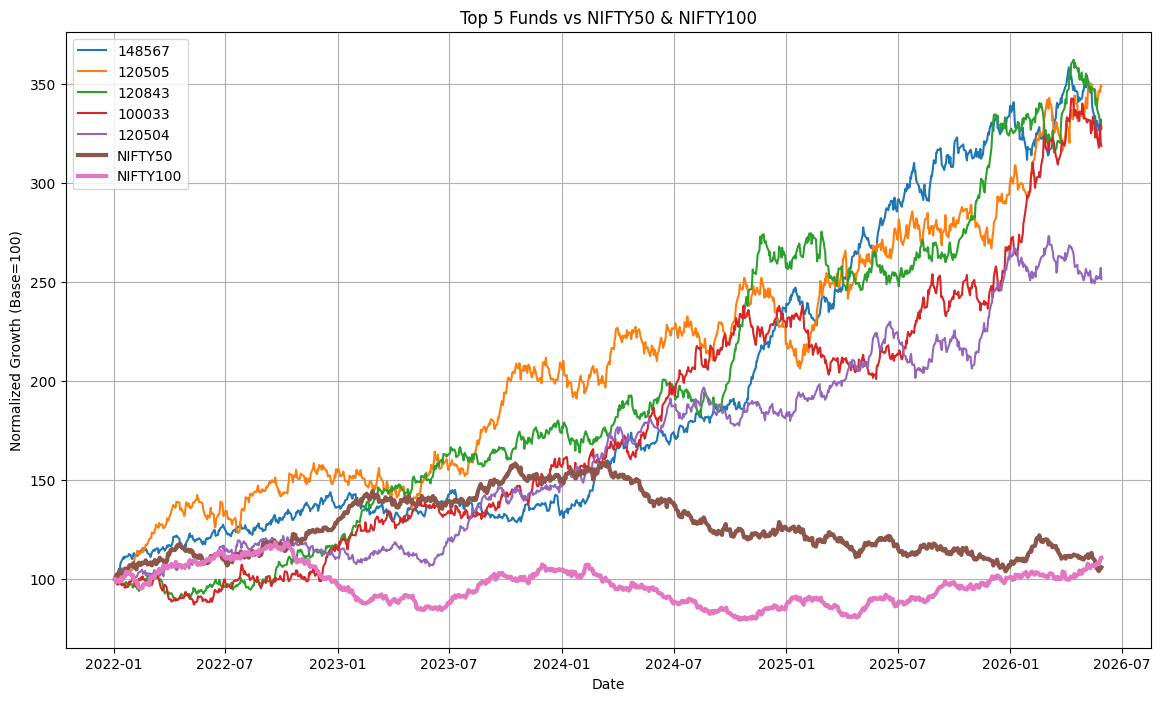

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/02_nav_history.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

top_codes = [
    148567,  # Mirae Asset Large Cap
    120505,  # ICICI Pru Midcap
    120843,  # Kotak Flexicap
    100033,  # HDFC Mid-Cap Opportunities
    120504   # ICICI Pru Bluechip
]

plt.figure(figsize=(14,8))

for code in top_codes:

    df = nav[nav['amfi_code'] == code].copy()

    if len(df) > 0:

        df = df.sort_values('date')

        df['normalized'] = (
            df['nav'] / df['nav'].iloc[0]
        ) * 100

        plt.plot(
            df['date'],
            df['normalized'],
            label=str(code)
        )

for idx in ['NIFTY50', 'NIFTY100']:

    b = benchmark[
        benchmark['index_name'] == idx
    ].copy()

    b = b.sort_values('date')

    b['normalized'] = (
        b['close_value'] /
        b['close_value'].iloc[0]
    ) * 100

    plt.plot(
        b['date'],
        b['normalized'],
        linewidth=3,
        label=idx
    )

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")
plt.xlabel("Date")
plt.ylabel("Normalized Growth (Base=100)")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()